## Pattern Recognition and Machine Learning - Assignment II
### Year 2025-2026- Semester II
### CCE2502
####  developed by - Adrian Muscat, 2026
---
### Write your name, ID Card Number below
Dave Galea 0283404L
---


In this assignment you will be developing Python code to experiment with the error based predictive models.


All questions are graded and total to 100.
This assignment contributes to a maximum of 30% of the final study unit score. 

In case of any ideas or expected results obtained from literature, cite the proper publication. In general you should not cite blogs (If you do use blogs or AI tools, trace the original document and cite that)

Submit on VLE:
1. This jupyter notebook complete with answers to the questions or tasks (.ipynb)
2. A pdf copy of the same jupyter notebook with all cells executed
3. The completed and signed plagiarism and collusion form

All zipped into one file.

NOTE: before you save your final file, **reset the kernel and execute all the cells**.

## NOTE: 

This work is to be attempted individually. It is essential that the work you eventually submit and present for your assignment consists only of your own work; use of copied material will be treated as plagiarism or collusion. Discussion is only permitted on general issues, and it is absolutely forbidden to discuss specific details with anyone and/or share results.

Below are links to the Plagiarism and Collusion form:

https://www.um.edu.mt/media/um/docs/faculties/ict/mainfacultyofictfiles/PlagiarismForm.pdf

or at:
https://www.um.edu.mt/ict/students/formsguidelines/

In [1]:
# Execute this to record library versions installed on your system
import matplotlib
import numpy
import sklearn
import sys

print("Python version : ", sys.version)
print("numpy version : ", numpy.__version__)
print("sklearn version : ", sklearn.__version__)
print("matplotlib version : ", matplotlib.__version__)

Python version :  3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
numpy version :  2.4.3
sklearn version :  1.8.0
matplotlib version :  3.10.8


# Part I

This part deals with the computation of the directional derivative used in gradient descent. The main gradient descent code and additional helper functions are given. You should have familiarised yourself with these functions during the lab sessions. There are three tasks in part I.

## Background

The main gradient descent code and additionalhelper functions are given below. 

In [2]:
# DO NOT MODIFY THIS CELL

import numpy as np
import matplotlib.pyplot as plt
import csv

# We first load the fish dataset
with open('Fish_Dataset_2020.csv', 'r') as f:
    reader = csv.reader(f)
    data_=[]
    for i,row in enumerate(reader):
        if i==0: print(row)
        else:
            data_.append(row)
data = np.array(data_,dtype=float)
#We take a look at the first 10 examples
data[0:10]

['Length', ' Width', ' Class(0=spnott', ' 1=awrat)']


array([[22.93,  7.24,  1.  ],
       [36.35,  9.97,  0.  ],
       [27.81, 10.4 ,  1.  ],
       [35.84, 11.25,  0.  ],
       [16.53,  5.56,  1.  ],
       [29.76,  8.1 ,  0.  ],
       [17.78,  6.31,  1.  ],
       [29.08,  8.37,  1.  ],
       [19.39,  7.85,  1.  ],
       [35.48, 10.41,  0.  ]])

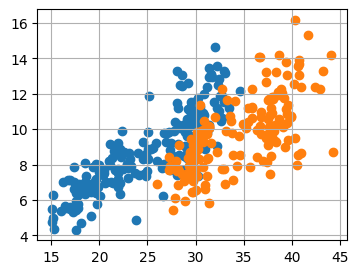

0

In [3]:
# DO NOT MODIFY THIS CELL
# helper function to plot the scatter diagram 
def plot_scatter(X, y, display = True):
    """
    X : features  (x1, x2)
    y : binary class  (0/1)
    """
    plt.figure(figsize=(4, 3))
    plt.scatter(X[y==1,0],X[y==1,1])
    plt.scatter(X[y==0,0],X[y==0,1])
    plt.grid()
    if display: 
        plt.show()
    return 0

plot_scatter(data[:,0:2], data[:,2])

In [4]:
# DO NOT MODIFY THIS CELL
# We now split the dataset into the train portion and the test portion
train_size = 0.7
np.random.seed(seed=1) # DO NOT CHANGE THE SEED
np.random.shuffle(data)
train_split = int(len(data)*train_size) # DO NOT CHANGE THE split ratio
print('Dataset size = ',len(data))
print ('Split dataset at ', train_split)
d_train=np.copy(data[0:train_split,:])
d_test = np.array(data[train_split:,:])
print ('Shape of train = ',np.shape(d_train))
print ('Shape of test = ',np.shape(d_test))

Dataset size =  355
Split dataset at  248
Shape of train =  (248, 3)
Shape of test =  (107, 3)


In [5]:
# DO NOT MODIFY THIS CELL
# normalisation
#
X_train_raw = np.copy(d_train[:,0:2])
y_train = np.copy(d_train[:,2])
X_test_raw = np.copy(d_test[:,0:2])
y_test = np.copy(d_test[:,2])
#
X_mean=X_train_raw.mean(axis=0)
X_var = X_train_raw.var(axis=0)
print(X_mean, X_var)
X_train = np.copy((X_train_raw - X_mean)/np.sqrt(X_var))
print('train mean',X_train.mean(axis=0))
print('train var',X_train.var(axis=0))
X_train.shape
#
X_test = np.copy((X_test_raw - X_mean)/np.sqrt(X_var))
print(X_test.mean(axis=0))
print(X_test.var(axis=0))
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

[29.26943548  9.31822581] [45.68616904  5.27849847]
train mean [ 3.67688630e-15 -6.71505862e-17]
train var [1. 1.]
[-0.01836152 -0.11731639]
[1.04976307 0.74404694]
(248, 2) (248,)
(107, 2) (107,)


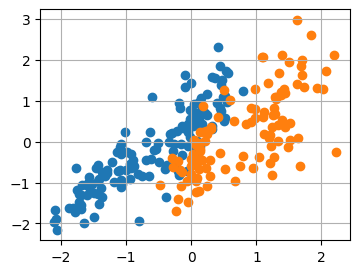

0

In [6]:
# plot the scatter diagram for the train set
plot_scatter(X_train, y_train)


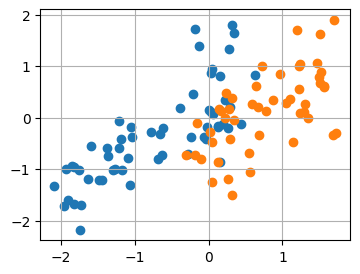

0

In [7]:
# plot the scatter diagram for the test set
plot_scatter(X_test, y_test)

Visually train and test split are similarly distributed and centered at (0,0)

In [8]:
# DO NOT MODIFY THIS CELL

def lr_loss_function(y_target,y_predicted):
    """
    inputs:
    y_target: actual target labels (vector of size(m,))
    y_predicted : predicted probabilities for positive class (vector of size (m,))

    outputs
    L:  cross entropy loss
    """
    #
    m = y_target.shape[0]
    # compute the cross-entropy loss
    
    L = -(y_target*np.log(y_predicted) + 
          (1-y_target)*np.log(1-y_predicted)).sum()/m
    
    return L
    
def predict_y_prob(W, D):
    """
    Inputs:
    W : the weight vector [[w_0],[w_1],[w_2],...] of size [N+1,1], where N is number of features, excluding bias
    D : is the feature matrix [m,N] where m is the number of examples

    Outputs:
    y: logits (probability of True Class)
    """
    
    m = D.shape[0]
    # Compute the probability 
    # of the positive class given the weights and features
    # for all m examples and return a vector of size (m,1)
    
    bias = np.ones([m,1], dtype=float)
    X = np.concatenate((bias,D),axis=1)
    z = np.matmul(W.T,X.T)
    y = 1/(1+np.exp(-z))
    
    return y.T

def get_accuracy(W, D, y):
    """
    Inputs
    W : the weight vector [[w_0],[w_1],[w_2],...] of size [N+1,1], where N is number of features, excluding bias
    D : the feature matrix [m,N] where m is the number of examples, excluding bias
    y : the target label vector of size (m,)

    Outputs:
    Accuracy (0...1)
    """
    
    # Compute the accuracy
    # in predicting the positive class and return a scalar
    
    Y_pred = (predict_y_prob(W, D)>=0.5).astype(int)
    acc = (Y_pred.ravel() == y).astype(int).sum()/y.shape[0]

    return acc


In [9]:
# DO NOT MODIFY THIS CELL
# The Gradient Descent algorithm

def lr_train_model(X_data, 
                   y_data, 
                   split_frac=0.8, 
                   init_weight=0.00001, 
                   no_iterations=2000,
                   alpha = 0.1):
    
    # prepare training and validation data
    split = int(y_data.shape[0]*split_frac)
    y_train = np.copy(y_data[0:split])
    y_val = np.copy(y_data[split:])
    X_train = np.copy(X_data[0:split])
    X_val = np.copy(X_data[split:])

    # initialise variables and weights
    N = X_data.shape[1] # number of features    
    m = y_train.shape[0] #number of training examples
    W = np.full((N+1,1), init_weight) # initialise weight vectors

    # save loss value per iteration
    history_loss=[]
    history_val_loss=[]

    #  Training loop
    for itr in range(no_iterations):
        y_pred_pr = predict_y_prob(W,X_train).ravel()
        loss = lr_loss_function(y_train,y_pred_pr)
        history_loss.append(loss)
        history_val_loss.append(lr_loss_function(y_val, predict_y_prob(W,X_val).ravel()))
        #
        
        W[0] = W[0] - alpha*(y_pred_pr - y_train).sum()/m
        
        for j in range(1,N+1):
            W[j] = W[j] - alpha*((y_pred_pr - y_train)*X_train[:,j-1]).sum()/m

    #
    return {'weights':W, 'history':{'train_loss':history_loss, 
                                    'val_loss':history_val_loss},
            'train_acc':get_accuracy(W,X_train,y_train),
            'val_acc':get_accuracy(W,X_val,y_val)}

def display_results(model):
    #
    history_train_loss = model['history']['train_loss']
    history_val_loss = model['history']['val_loss']
    t=range(len(history_train_loss))
    p1, p2 = plt.plot(t,history_train_loss,'b',t,history_val_loss,'r')
    plt.legend([p1,p2], ['Train loss','Val loss'])
    #
    print('train acc : ', model['train_acc'])
    print('val acc   : ', model['val_acc'])
    #
    print('Weights : ', model['weights'].ravel())
    plt.show()
    return 0

train acc :  0.8939393939393939
val acc   :  0.94
Weights :  [ 0.63331016 -6.5782824   3.00937796]


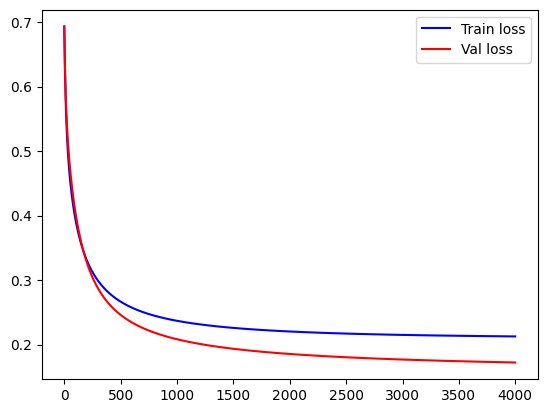

0

In [10]:
# DO NOT MODIFY THIS CELL
lr_fish_model = lr_train_model(X_train, y_train,split_frac=0.8, 
                   init_weight=0.00001, no_iterations=4000,
                   alpha = 0.1)
display_results(lr_fish_model)

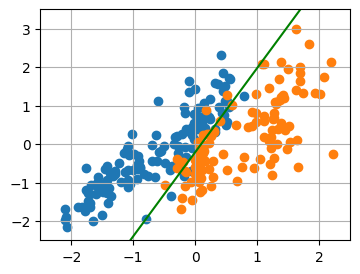

In [11]:
# DO NOT MODIFY THIS CELL
# We now plot the decision boundary on the scatter plot

plot_scatter(X_train, y_train, display=False)

# Define boundary and plot
cc = -lr_fish_model['weights'][0]/lr_fish_model['weights'][2]
mm = -lr_fish_model['weights'][1]/lr_fish_model['weights'][2]
xx = np.linspace(-2.5, 2.5, 10)
yy = cc + mm*xx
plt.plot(xx, yy,'g')
plt.axis([-2.5, 2.5, -2.5, 3.5])
plt.show()


# Task I_a 

In the first task you will carry out the gradient computation in a separate function and use the returned value in main gradient descent loop. Complete the below analytical_gradient() function and use the result in the gradient descent main loop. The gradient descent function is copied further below with the parts you need to modify marked in between ###...####  and ###...####. Check that you obtain the same output as the output obtained in the background section above. 

## [10 marks]

In [12]:
# MODIFY THIS CELL (Task I_a)
# Computing the gradients

def analytical_gradient(y_pred, y_target, X):
    """
    inputs:
    y_pred :  predicted probabilities vector of size (m,)  m is number of instances in X
    y_target : target values {0,1}  vector of size (m,)
    X :  input variables (features) used in training loop 

    outputs:
    grad : gradients computed analytically, vector of size (N,)
    
    """
    #################################################################################        
    # Write your code below 
    m = X.shape[0] # m = number of instances in x 

    # error term
    error = (y_pred - y_target) 

    N = X.shape[1]
    grad = np.zeros(N+1) # gradient vector is of size features (N) + 1 for bias 

    #bias gradient
    grad[0] = error.sum()/m  # average error across all samples 

    # Feature gradient
    for j in range(N):
        grad[j+1] = np.sum(error * X[:, j]) /m # average of (error x feature j) across all samples 
    #################################################################################
    
    return grad 

In [13]:
# MODIFY THIS CELL (Task I_a)
# The Gradient Descent algorithm

def lr_train_model(X_data, 
                   y_data, 
                   split_frac=0.8, 
                   init_weight=0.00001, 
                   no_iterations=2000,
                   alpha = 0.1):
    
    # prepare training and validation data
    split = int(y_data.shape[0]*split_frac)
    y_train = np.copy(y_data[0:split])
    y_val = np.copy(y_data[split:])
    X_train = np.copy(X_data[0:split])
    X_val = np.copy(X_data[split:])

    # initialise variables and weights
    N = X_data.shape[1] # number of features    
    m = y_train.shape[0] #number of training examples
    W = np.full((N+1,1), init_weight) # initialise weight vectors

    # save loss value per iteration
    history_loss=[]
    history_val_loss=[]

    #  Training loop
    for itr in range(no_iterations):
        y_pred_pr = predict_y_prob(W,X_train).ravel()
        loss = lr_loss_function(y_train,y_pred_pr)
        history_loss.append(loss)
        history_val_loss.append(lr_loss_function(y_val, predict_y_prob(W,X_val).ravel()))
        #

        #################################################################################
        # change code below in task I_a
        grad = analytical_gradient(y_pred_pr, y_train, X_train) # compute full gradient
        W[0] = W[0] - alpha* grad[0] # update bias 
        #################################################################################
        #

        
        
        #################################################################################        
        # change code below in task I_a
        for j in range(1,N+1):
            W[j] = W[j] - alpha*grad[j] # update features
        #################################################################################

    #
    return {'weights':W, 'history':{'train_loss':history_loss, 
                                    'val_loss':history_val_loss},
            'train_acc':get_accuracy(W,X_train,y_train),
            'val_acc':get_accuracy(W,X_val,y_val)}

def display_results(model):
    #
    history_train_loss = model['history']['train_loss']
    history_val_loss = model['history']['val_loss']
    t=range(len(history_train_loss))
    p1, p2 = plt.plot(t,history_train_loss,'b',t,history_val_loss,'r')
    plt.legend([p1,p2], ['Train loss','Val loss'])
    #
    print('train acc : ', model['train_acc'])
    print('val acc   : ', model['val_acc'])
    #
    print('Weights : ', model['weights'].ravel())
    plt.show()
    return 0

train acc :  0.8939393939393939
val acc   :  0.94
Weights :  [ 0.63331016 -6.5782824   3.00937796]


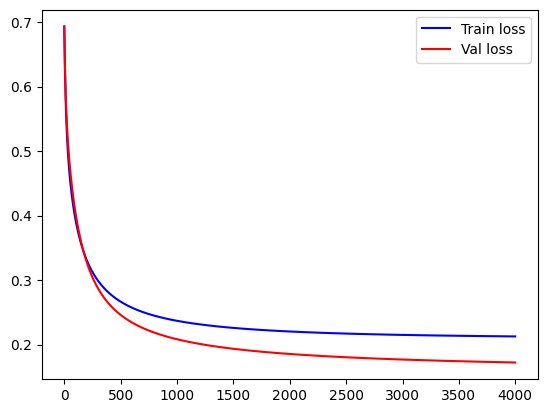

0

In [14]:
# DO NOT MODIFY THIS CELL
lr_fish_model = lr_train_model(X_train, y_train,split_frac=0.8, 
                   init_weight=0.00001, no_iterations=4000,
                   alpha = 0.1)
display_results(lr_fish_model)

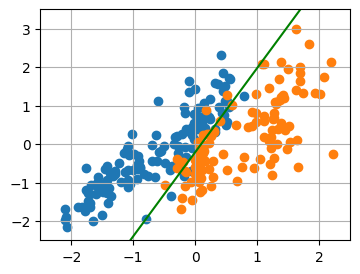

In [15]:
# DO NOT MODIFY THIS CELL
# We now plot the decision boundary on the scatter plot

plot_scatter(X_train, y_train, display=False)

# Define boundary and plot
cc = -lr_fish_model['weights'][0]/lr_fish_model['weights'][2]
mm = -lr_fish_model['weights'][1]/lr_fish_model['weights'][2]
xx = np.linspace(-2.5, 2.5, 10)
yy = cc + mm*xx
plt.plot(xx, yy,'g')
plt.axis([-2.5, 2.5, -2.5, 3.5])
plt.show()

# Task I_b

The parial derivatives with respect to each weight will now be approximated using the below forward difference equation. In other words the value of $w_j$ is increased by a small amount ($\epsilon$) to compute the derivative of the loss wrt $w_j$. The approximation is then used in the gradient descent update equations.

$$ \frac{\partial L}{\partial w_j} \approx \frac{L(w_0, ..., w_j + \epsilon, ..., w_N) - L(w_0, ..., w_j, ..., w_N)}{\epsilon}$$

1. Complete the function below to obtain a numerical approximation of the gradient and use the numerical approximation inside the gardient descent loop instead of the analytical gradient. (You will need to copy the gradient descent algorithm as modified in task I_a and replace analytical_gradient() function with numerical_gradient() function)
2. Compare the results to those obtained with the analytical gradient computation.

## [20 marks]

In [16]:
# MODIFY THIS CELL (Task I_b)
# Computing the gradients numerically

def numerical_gradient(y_pred, y_target, X, Weights, eps=0.0001):
    """
    inputs:
    y_pred :  predicted probabilities vector of size (m,)  m is number of instances in X
    y_target : target values {0,1}  vector of size (m,)
    X :  input variables (features) used in training loop 
    Weights: vector of size (N+1,1), N is number of features, plus bias
    eps : delta_w to compute gradient

    outputs:
    grad : gradients computed numerically, vector of size (N,)
    
    """

    #################################################################################        
    # Write your code below 
    ...
    
    ...
    #################################################################################
    
    return grad

In [17]:
# COPY and MODIFY lr_train_model() here 
...

Ellipsis

train acc :  0.8939393939393939
val acc   :  0.94
Weights :  [ 0.63331016 -6.5782824   3.00937796]


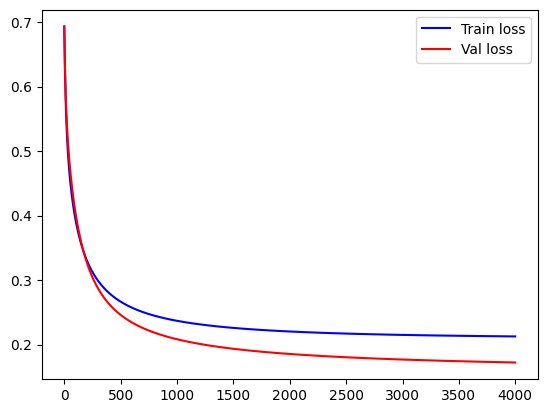

0

In [18]:
# DO NOT MODIFY THIS CELL
lr_fish_model = lr_train_model(X_train, y_train,split_frac=0.8, 
                   init_weight=0.00001, no_iterations=4000,
                   alpha = 0.1)
display_results(lr_fish_model)

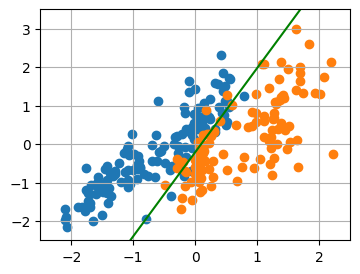

In [19]:
# DO NOT MODIFY THIS CELL
# We now plot the decision boundary on the scatter plot

plot_scatter(X_train, y_train, display=False)

# Define boundary and plot
cc = -lr_fish_model['weights'][0]/lr_fish_model['weights'][2]
mm = -lr_fish_model['weights'][1]/lr_fish_model['weights'][2]
xx = np.linspace(-2.5, 2.5, 10)
yy = cc + mm*xx
plt.plot(xx, yy,'g')
plt.axis([-2.5, 2.5, -2.5, 3.5])
plt.show()

# Task I_c

We can consider replacing the sigmoid function with a piecewise linear approximation, known as the HardSigmoid(z) function. 

The HardSigmoid(z) function is defined as follows:
$$
\mathrm{HardSigmoid}(x) =
\begin{cases}
0 & \text{if } x \le -2.5 \\
0.2x + 0.5 & \text{if } -2.5 < x < 2.5 \\
1 & \text{if } x \ge 2.5
\end{cases}
$$

1. Plot the HardSigmoid() superimposed on the Sigmoid() (in Python)
2. Assumin we use the HardSigmoid() in our model, explain how the gradients wrt $w_j$ are computed (DO NOT implement in python)
3. Explain the advantages and disadvantages of using a HardSigmoid instead of the standard sigmoid function.

## [20 marks]

In [20]:
# PLOT here
...

Ellipsis

##### EXPLAIN here
...

# Part II

It is required to install a Feed-Forward-Fully-Connected Neural Network (FFFC-NN) in a small low-power edge device on which the forward and backward computations are carried out on a CPU (i.e serial). The memory available to store and update the Neural Network weights is 130kBytes. i.e. Accuracy may have to be traded off to fit the model in the memory space available. 

Carry out the below tasks using the sk-learn.neural_network module and the given dataset.

In [21]:
# DO NOT MODIFY THIS CELL

#Import dataset
import pickle

with open("Task_II_dataset.pkl", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2400, 10), (2400,), (600, 10), (600,))

# Task II_a

Explain how you can calculate the amount of memory required to store the weights and compute the output of the neural network. In addition explain how you can measure the memory occupied by the weights and feed-forward computations in your sk-learn model. 

## [10 marks]

#### WRITE Your answer here
...

# Task II_b

Train and optimise a neural network that fits in the memory of the edge device and compute the final accuracy on the test set. (You should NOT use the test set at any time during training and optimising)

## [30 marks]

In [22]:
# YOUR CODE HERE
...

Ellipsis

# Task II_c
Through calculation and measurement, show that your model fits the requirements.

## [10 marks]

In [23]:
# YOUR ANSWER HERE
...

Ellipsis